# **Atividade Prática**
<font size=3>

- **Tema:** *word-embedding*.
- **Prazo de entrega:** 25 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Questão 1:**
<font size=3>

Com base no *dataset* de [Transcrição de TED Talks](https://www.kaggle.com/datasets/miguelcorraljr/ted-ultimate-dataset), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos para resolver a **tarefa de regressão**:

### **1º Passo:**

<font size=3>

- Importe o *dataset* e defina o atributo `description` como a lista de dados textuais e `views` como a variável alvo para regressão;
- **Imprima na tela** o tamanho mínimo, o máximo e a média do comprimento das sentenças.


In [1]:
# Os arquivos estão disponiveis localmente, não é necessario montar o drive
#from google.colab import drive
#drive.mount('/content/drive/')

In [2]:
from keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf

In [3]:
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', None) 
df = pd.read_csv('./dataset/ted_talks.csv')
df.head()[['description', 'views']]

,description,views
0,"With the same humor and humanity he exuded in ""An Inconvenient Truth,"" Al Go...",3523392
1,You've never seen data presented like this. With the drama and urgency of a ...,14501685
2,New York Times columnist David Pogue takes aim at technology’s worst interfa...,1920832
3,"In an emotionally charged talk, MacArthur-winning activist Majora Carter det...",2664069
4,Sir Ken Robinson makes an entertaining and profoundly moving case for creati...,65051954


In [4]:
X = df['description']
y = df['views']

X_len = X.str.len()

print(f"Tamanho mínimo: {X_len.min()}")
print(f"Tamanho máximo: {X_len.max()}")
print(f"Tamanho médio.: {X_len.mean():.0f}")
print(f"Mediana.......: {X_len.median():.0f}")
print(f"Desvio padrão.: {X_len.std():.0f}")


Tamanho mínimo: 52
Tamanho máximo: 907
Tamanho médio.: 353
Mediana.......: 349
Desvio padrão.: 116


### **2º Passo:**

<font size=3>

- **2.1**: Realize a normalização da variável alvo (considerando sua adequação à função de atividação da camada de saída);
- **2.2**: Defina o objeto da vetorização dos dados textuais com a função [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/):
    - A variável `standardize` tem como *default* `"lower_and_strip_punctuation"`, mas esta variável pode receber um pré-processador customizado com *regex*, por exemplo:
    
  <font size=2>
  
  ```python
  
        import tensorflow.strings as tf_strings
        
        def Preprocessor(x):
        
            x = tf.strings.lower(x)
            x = tf.strings.regex_replace(x, r"[^\w\s]", "")
    
            return x
            
    ```
    <font size=3>
  
    - Defina o tamanho do vocabulário (`vocab_size`), o tamanho da entrada/janela do modelo (`max_len`), e a dimensão do vetor *embedding* (`embed_dim`);
    - Iremos realizar a vetorização (indexação) dentro da rede neural, ou seja, o objeto da vetorização irá processar os dados após a camada `layers.Input()`.
    <br>

- **2.3**: Divida os dados em treinamento (90%) e teste (10%). Os dados de validação serão divididos na função `model.fit()`. 

#### **2.1**: Normalização da variável alvo

Para propor uma normalização vamos primeiro analisar a distribuição dos dados de views. Para isso vamos criar uma função auxiliar que mostra uma breve descrição estatística da amostra.

In [5]:
def br_number(value, decimals=0):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "X").replace(".", ",").replace("X", ".")

In [6]:
def descrever_variavel_numerica(y, nome="variável", decimals=0):
    '''
    Descreve uma variável numérica com percentis e assimetria.
    '''
    percentis = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]

    print(f"=== Percentis de {nome} ===")

    for p in percentis:
        valor = y.quantile(p)
        qtd_acumulada = (y <= valor).sum()

        print(
            f"P {int(p * 100):>3}%:"
            f" {br_number(valor, decimals):>15}"
            f" | qtd acumulada: {qtd_acumulada:>5}"
        )

    print()

    print(f"=== Assimetria de {nome} ===")
    print(f"{'Média':<10}: {br_number(y.mean(), decimals):>15}")
    print(f"{'Mediana':<10}: {br_number(y.median(), decimals):>15}")
    print(f"{'Mínimo':<10}: {br_number(y.min(), decimals):>15}")
    print(f"{'Máximo':<10}: {br_number(y.max(), decimals):>15}")
    print(f"{'Skewness':<10}: {br_number(y.skew(), 2):>15}")
    print()

E executamos a função para a variavel numérica ```y```

In [7]:
descrever_variavel_numerica(y, "views")

=== Percentis de views ===
P   0%:               0 | qtd acumulada:     6
P   1%:          39.088 | qtd acumulada:    41
P   5%:         296.171 | qtd acumulada:   201
P  10%:         466.915 | qtd acumulada:   401
P  25%:         882.069 | qtd acumulada:  1002
P  50%:       1.375.508 | qtd acumulada:  2003
P  75%:       2.133.110 | qtd acumulada:  3004
P  90%:       3.994.610 | qtd acumulada:  3604
P  95%:       6.182.301 | qtd acumulada:  3804
P  99%:      16.299.834 | qtd acumulada:  3964
P 100%:      65.051.954 | qtd acumulada:  4005

=== Assimetria de views ===
Média     :       2.148.006
Mediana   :       1.375.508
Mínimo    :               0
Máximo    :      65.051.954
Skewness  :            8,19



Temos uma métrica de assimetria (skewness) indicando que a distribuição tem forte desvio positivo. Vamos investigar melhor essa distribuição através de um histograma onde marcaremos também os principais percentis. Para isso também vamos criar uma função que exibe um histograma dos dados, juntamente com os percentis que desejamos marcar no grafico.

In [8]:
from matplotlib.ticker import FuncFormatter

def formatar_milhoes_br(x, pos):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    return f"{x / 1_000_000:.1f}".replace(".", ",")


def plotar_histograma_com_percentis(
    y,
    nome="variável",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=True
):
    '''
    Plota um histograma dos dados, juntamente com os percentis que desejamos marcar no grafico.
    '''
    limite = y.quantile(limite_percentil)
    y_filtrado = y[y <= limite]

    plt.figure(figsize=(12, 6))
    plt.hist(y_filtrado, bins=bins, edgecolor="black", alpha=0.7)

    if usar_milhoes:
        plt.gca().xaxis.set_major_formatter(FuncFormatter(formatar_milhoes_br))
        xlabel = f"{nome} em milhões"
    else:
        xlabel = nome

    altura_max = plt.ylim()[1]

    for p in percentis_marcados:
        valor = y.quantile(p)

        if valor <= limite:
            plt.axvline(valor, linestyle="--", linewidth=1.5, alpha=0.8)
            plt.text(
                valor,
                altura_max * 0.95,
                f"P{int(p * 100)}",
                rotation=90,
                ha="center",
                va="top"
            )

    plt.title(f"Distribuição de {nome} até o percentil {int(limite_percentil * 100)}")
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

E geramos o histograma a partir de ```y```

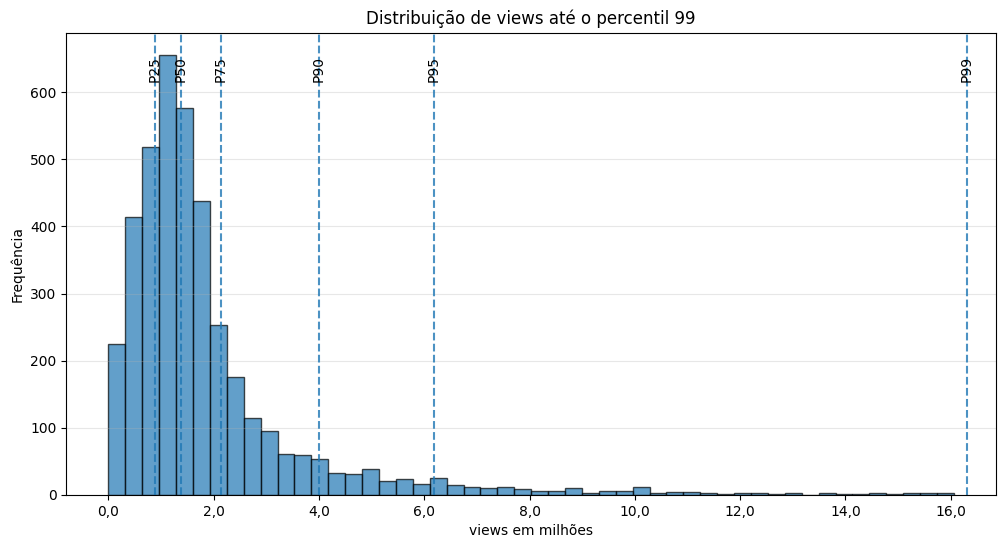

In [9]:
plotar_histograma_com_percentis(y, nome="views")

A distribuição de views apresenta forte assimetria positiva. Embora 75% dos registros estejam abaixo de aproximadamente 2,1 milhões de visualizações, os percentis superiores crescem rapidamente, chegando a cerca de 16,3 milhões no P99 e 65 milhões no valor máximo. 

Isso indica que uma normalização MinMax direta seria fortemente influenciada pelos valores extremos, comprimindo a maior parte dos dados em uma faixa pequena. Assim, faz sentido investigar uma transformação logarítmica, que pode reduzir o efeito da cauda longa antes do treinamento da rede neural.

Primeiro executamos a transformação ```np.log1p(y)```, que conforme sua definição, aplicará a função abaixo a y: $$y\_log = log_e(1 + y)$$

In [10]:
y_log = np.log1p(y)

Em seguida vamos descrever a nova variável numérica y_log:

In [11]:

descrever_variavel_numerica(y_log, "log1p(views)", decimals=2)

=== Percentis de log1p(views) ===
P   0%:            0,00 | qtd acumulada:     6
P   1%:           10,57 | qtd acumulada:    41
P   5%:           12,60 | qtd acumulada:   201
P  10%:           13,05 | qtd acumulada:   401
P  25%:           13,69 | qtd acumulada:  1002
P  50%:           14,13 | qtd acumulada:  2003
P  75%:           14,57 | qtd acumulada:  3004
P  90%:           15,20 | qtd acumulada:  3604
P  95%:           15,64 | qtd acumulada:  3804
P  99%:           16,61 | qtd acumulada:  3964
P 100%:           17,99 | qtd acumulada:  4005

=== Assimetria de log1p(views) ===
Média     :           14,10
Mediana   :           14,13
Mínimo    :            0,00
Máximo    :           17,99
Skewness  :           -3,52



E também gerar o respectivo histograma de y_log:

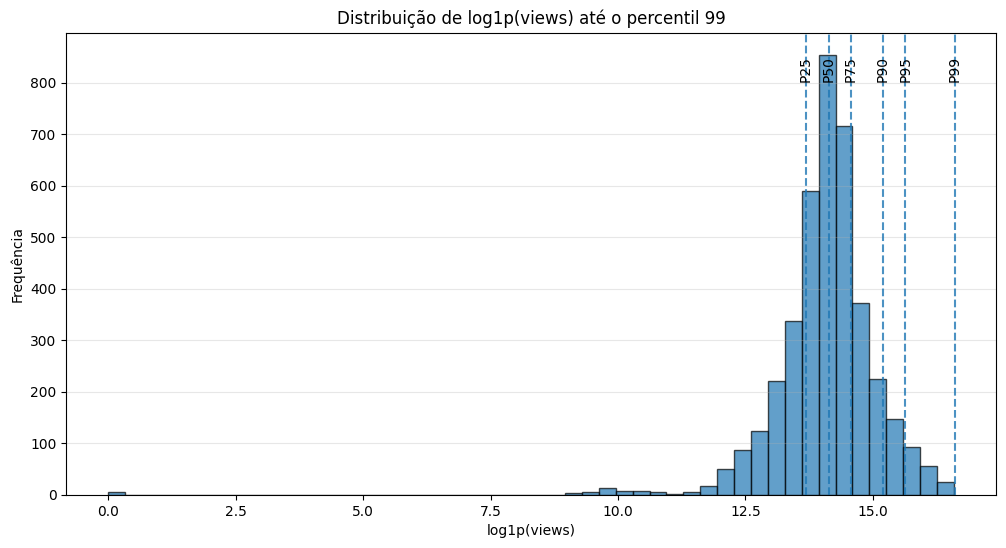

In [12]:
plotar_histograma_com_percentis(
    y_log,
    nome="log1p(views)",
    usar_milhoes=False
)

Mesmo após a transformação ```np.log1p(y)```, ainda existem valores extremos, principalmente associados aos registros com views = 0 e aos valores mais altos da distribuição. No entanto, a transformação logarítmica reduziu de forma relevante a cauda longa original.

Como o modelo será treinado por uma rede neural, também faz sentido aplicar uma normalização MinMax sobre ```np.log1p(y)```, colocando a variável alvo em uma faixa numérica controlada entre 0 e 1. Isso trata a escala numérica de forma a facilitar o aprendizado da rede neural.

Assim, combinamos duas etapas com objetivos diferentes: a transformação logarítmica reduz a assimetria da distribuição, enquanto a normalização MinMax ajusta a escala da variável para o treinamento do modelo.

É importante lembrar que a rede neural aprenderá o alvo transformado. Logo, para obter o valor original de views, será necessário aplicar as transformações inversas na ordem correta: primeiro a inversa do ```MinMaxScaler``` e depois ```np.expm1```.

Vamos aplicar a seguir a transformação ```MinMaxScaler``` sobre ```np.log1p(y)```:

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(
        y_log.values.reshape(-1, 1) # reshape para 2D necessario para o fit_transform
    ).ravel() #ravel para retornar um array unidimensional

y_scaled = pd.Series(y_scaled, index=y.index, name="MinMaxScaler(log1p(views))")

E descrever o resultado final nos mesmos termos que ocupamos antes para deixar registro:

In [14]:
descrever_variavel_numerica(
    y_scaled,
    "MinMax(log1p(views))",
    decimals=2
)

=== Percentis de MinMax(log1p(views)) ===
P   0%:            0,00 | qtd acumulada:     6
P   1%:            0,59 | qtd acumulada:    41
P   5%:            0,70 | qtd acumulada:   201
P  10%:            0,73 | qtd acumulada:   401
P  25%:            0,76 | qtd acumulada:  1002
P  50%:            0,79 | qtd acumulada:  2003
P  75%:            0,81 | qtd acumulada:  3004
P  90%:            0,84 | qtd acumulada:  3604
P  95%:            0,87 | qtd acumulada:  3804
P  99%:            0,92 | qtd acumulada:  3964
P 100%:            1,00 | qtd acumulada:  4005

=== Assimetria de MinMax(log1p(views)) ===
Média     :            0,78
Mediana   :            0,79
Mínimo    :            0,00
Máximo    :            1,00
Skewness  :           -3,52



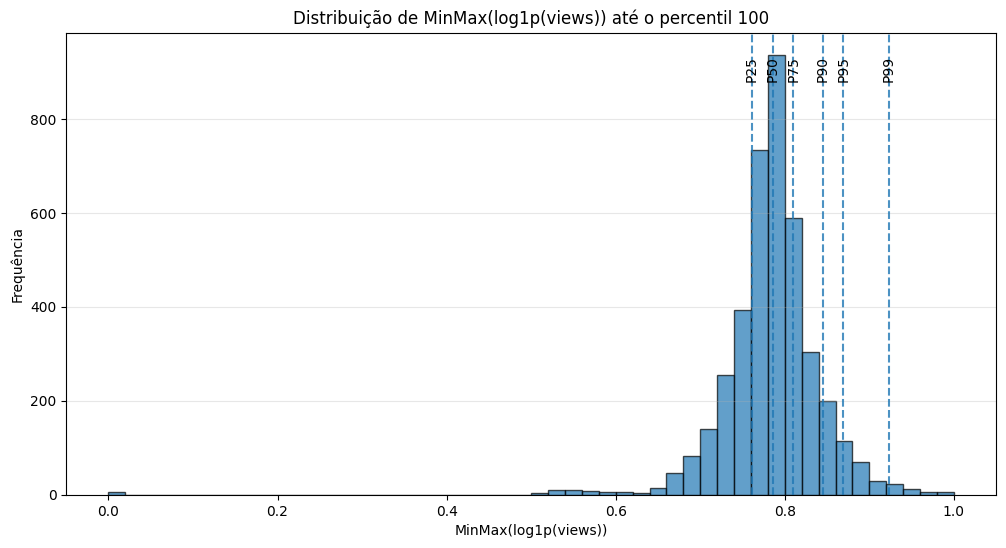

In [15]:
plotar_histograma_com_percentis(
    y_scaled,
    nome="MinMax(log1p(views))",
    limite_percentil=1.00,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=False
)

Podemos observar que o formato do histograma continua igual ao anterior, bem como a métrica de assimetria (skewness), modificando apenas a escala numérica, agora entre 0 e 1. Esse era justamente o objetivo da última transformação. 

**A partir deste ponto, nossa variável alvo passa a ser ```y_scaled```. Para obter a previsão original em views, será necessário aplicar a transformação inversa na ordem correta: primeiro a inversa do ```MinMaxScaler``` e depois ```np.expm1```.** 

Pode haver um erro desprezível devido a arredondamento e/ou precisão numérica nessa transformação inversa, mas isso é aceitável.

#### **2.2**: Definição de vetorização textual

Primeiro definimos nossa função de pré-processamento. Vamos deixar a função externalizada para facilitar modificações futuras, caso seja necessário ajustar alguma regex por qualquer motivo.

In [16]:
def Preprocessor(x):

    x = tf.strings.lower(x)
    x = tf.strings.regex_replace(x, r"[^\w\s]", "")
    x = tf.strings.regex_replace(x, r" {2,}", " ")
    x = tf.strings.strip(x)

    return x

print (Preprocessor("   Hello,   the  world's  !   ").numpy().decode("utf-8"))

hello the worlds


Em seguida definimos nosso vetorizador textual e algumas constantes utilizadas ao longo do processo.

In [17]:
VOCAB_SIZE = 10000
MAX_LEN = 100
EMBED_DIM = 64 # será utilizado depois para a camada de embedding

text_vectorizer = layers.TextVectorization(
    name="TextVectorizer",
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN,
    standardize=Preprocessor
)

#### **2.3**: Divisão de dados em treinamento e validação

Vamos utilizar a função [```train_test_split```](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do scikit-learn para separar os conjuntos de treino e teste.

In [18]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.10

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_scaled,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

Por fim, descobrimos o vocabulário a partir do conjunto de treinamento, deixando propositadamente o conjunto de validação de fora:

In [19]:
text_vectorizer.adapt(X_train)

Definimos uma função simples para exibir uma amostragem do vocabulario aprendido:

In [20]:
def mostrar_amostra_vocabulario(vocab, n=10, random_state=42):
    tokens_especiais = ["", "[UNK]"]

    vocab_tokens = [
        str(token) for token in vocab
        if token not in tokens_especiais
    ]

    n = min(n, len(vocab_tokens))

    rng = np.random.default_rng(random_state)

    df_vocab = pd.DataFrame({
        "top": vocab_tokens[:n],
        "bottom": vocab_tokens[-n:],
        "random": rng.choice(vocab_tokens, size=n, replace=False).tolist()
    })

    print("=== Amostra do vocabulário aprendido ===")
    print(f"Tamanho total do vocabulário: {len(vocab)}")
    print(f"Tamanho sem tokens especiais: {len(vocab_tokens)}")
    print(f"Retornando DataFrame com N={n} tokens top, bottom e random.")

    return df_vocab

E mostramos os N top/bottom tokens e os N tokens aleatorios do vocabulário.

In [21]:
N=10
df_vocab = mostrar_amostra_vocabulario(
    text_vectorizer.get_vocabulary(),
    n=N,
    random_state=RANDOM_STATE
)

df_vocab.head(N)

=== Amostra do vocabulário aprendido ===
Tamanho total do vocabulário: 10000
Tamanho sem tokens especiais: 9998
Retornando DataFrame com N=10 tokens top, bottom e random.


,top,bottom,random
0,the,completing,minds
1,and,competitor,slogan
2,of,competitions,robert
3,to,compelled,frontlines
4,a,comparing,devastation
5,in,compare,explosion
6,that,companions,bay
7,by,communicates,complicated
8,for,commonsense,greater
9,how,commits,mistry


### **3º Passo:**

<font size=3>

- **3.1**: Desenvolva a primeira versão da **arquitetura neural**:
    - Já sabemos o tamanho da entrada, o tamanho da saída e sua função de ativação:
 
        <font size=2>
        
        ```python
        x_in = layers.Input(shape=(1, ), dtype=tf.string)
            
        ```
        <font size=3>
        
    - A camada [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) irá retornar um *array* de formato (`max_len`, `embed_dim`), assim, precisamos torná-lo unidimensional para poder ser acoplado à próxima camada. Para isso, utilize:
        - Uma camada de [`Flatten`](https://keras.io/api/layers/reshaping_layers/flatten/);
        - Ou uma camada de [`GlobalAveragePooling1D`](https://keras.io/api/layers/pooling_layers/global_average_pooling1d/).
        <br>

- **3.2**: **Escreva** em uma **célula _markdown_** a diferença entre as camadas `Flatten` e `GlobalAveragePooling1D`;

- **3.3**: Compile o modelo com um otimizador ([`SGR`](https://keras.io/api/optimizers/sgd/), [`RMSprop`](https://keras.io/api/optimizers/rmsprop/), [`Adam`](https://keras.io/api/optimizers/adam/));
- **3.4**: Defina a função de perda e métrica de acordo com a natureza do problema.
  

#### **3.1**: Desenvolvimento da primeira versão da **arquitetura neural**

Como a questão seguinte solicita explicação sobre a diferença entre GlobalAveragePooling1D e Flatten, vamos desenvolver um núcleo comum de processamento de embedding primeiro.

In [22]:
x_in = layers.Input(
    shape=(1,), 
    dtype=tf.string,
    name="Entrada de dados")

x = text_vectorizer(x_in)

x = layers.Embedding(
    name="Gerador de Embedding",
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    input_length=MAX_LEN
)(x)

/Users/gilcesarf/git/repositories/imd/imd1107-202601/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Em seguida vamos criar dois fluxos paralelos, um com GlobalAveragePooling1D e outro com Flatten, sufixando as respectivas variáveis.

In [23]:

x_pooling = layers.GlobalAveragePooling1D(name="Representação vetorial")(x)
x_flatten = layers.Flatten(name="Representação vetorial")(x)

x_pooling = layers.Dense(64, activation="relu", name="Camada densa 1")(x_pooling)
x_flatten = layers.Dense(64, activation="relu", name="Camada densa 1")(x_flatten)

x_pooling = layers.Dense(32, activation="relu", name="Camada densa 2")(x_pooling)
x_flatten = layers.Dense(32, activation="relu", name="Camada densa 2")(x_flatten)

y_out_pooling = layers.Dense(1, activation="linear", name="Saída")(x_pooling)
y_out_flatten = layers.Dense(1, activation="linear", name="Saída")(x_flatten)

Por fim criamos o primeiro modelo com o GlobalAveragePooling1D:

In [24]:

model_pooling = Model(
    name="Modelo de regressão com embedding + GlobalAveragePooling1D",
    inputs=x_in, 
    outputs=y_out_pooling)

model_pooling.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_pooling.summary()


Model: "Modelo de regressão com embedding + GlobalAveragePooling1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada de dados (InputLayer)   │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TextVectorizer                  │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Gerador de Embedding            │ (None, 100, 64)        │       640,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Representação vetorial          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Camada densa 1 (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Camada densa 2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saída (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,273 (2.47 MB)

 Trainable params: 646,273 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

E finalizamos com o modelo utilizando Flatten:

In [25]:

model_flatten = Model(
    name="Modelo de regressão com embedding + Flatten",
    inputs=x_in, 
    outputs=y_out_flatten)

model_flatten.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_flatten.summary()


Model: "Modelo de regressão com embedding + Flatten"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada de dados (InputLayer)   │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TextVectorizer                  │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Gerador de Embedding            │ (None, 100, 64)        │       640,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Representação vetorial          │ (None, 6400)           │             0 │
│ (Flatten)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Camada densa 1 (Dense)          │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Camada densa 2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saída (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,777 (4.01 MB)

 Trainable params: 1,051,777 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

#### **3.2**: Explicando diferença entre `Flatten` e `GlobalAveragePooling1D`

Para explicar a diferenção entre `GlobalAveragePooling1D` e `Flatten` vamos primeiro montar uma tabela comparativa dos dois modelos, onde pareamos para cada etapa do modelo as dimensões de saída e a quantidade de parâmetros correspondente, quando aplicável.

Primeiro criamos uma função que extrai os dados relevantes de um modelo:

In [26]:
def extrair_resumo_modelo(model, nome_coluna):
    dados = []

    for ordem, layer in enumerate(model.layers):
        dados.append({
            "Ordem": ordem,
            "Camada": layer.name,
            f"Saída {nome_coluna}": str(layer.output.shape),
            f"Parâmetros {nome_coluna}": layer.count_params()
        })

    return pd.DataFrame(dados)

Aplicamos a função para os dois modelos:

In [27]:
df_pooling = extrair_resumo_modelo(model_pooling, "Pooling 1D")
df_flatten = extrair_resumo_modelo(model_flatten, "Flatten")

Juntamos os dois dataframes para permitir a comparação e exibimos o resultado:

In [28]:
df_comparacao = pd.merge(
    df_pooling,
    df_flatten,
    on=["Ordem", "Camada"],
    how="outer"
)

df_comparacao = df_comparacao.sort_values("Ordem").drop(columns="Ordem")

df_comparacao

,Camada,Saída Pooling 1D,Parâmetros Pooling 1D,Saída Flatten,Parâmetros Flatten
0,Entrada de dados,"(None, 1)",0,"(None, 1)",0
1,TextVectorizer,"(None, 100)",0,"(None, 100)",0
2,Gerador de Embedding,"(None, 100, 64)",640000,"(None, 100, 64)",640000
3,Representação vetorial,"(None, 64)",0,"(None, 6400)",0
4,Camada densa 1,"(None, 64)",4160,"(None, 64)",409664
5,Camada densa 2,"(None, 32)",2080,"(None, 32)",2080
6,Saída,"(None, 1)",33,"(None, 1)",33


Através de uma simples observação, podemos identificar que a principal diferença numérica entre as duas abordagens está na quantidade de parâmetros da Camada densa 1. Enquanto `GlobalAveragePooling1D` gera apenas 4.160 parâmetros, `Flatten` gera 409.664 parâmetros: uma diferença muito grande. A seguir explicamos o motivo dessa diferença.

A operação `Flatten` simplesmente concatena os vetores que representam cada token da descrição. Como cada descrição foi limitada a 100 tokens e cada token é representado por um vetor de 64 posições, a saída da camada de embedding possui formato (100, 64). Ao aplicar `Flatten`, essa matriz é achatada em um único vetor com 100 × 64 = 6.400 posições.

Já a operação `GlobalAveragePooling1D` não concatena todos os tokens. Ela calcula a média em cada posição dos vetores dos tokens, preservando as 64 dimensões do embedding. Depois dela, a descrição passa a ser representada por um único vetor de 64 posições, que pode ser entendido como uma espécie de média dos embeddings dos tokens que compõem a descrição.

Em termos numéricos, `Flatten` transforma cada descrição em um vetor com 64 × 100 = 6.400 posições, enquanto `GlobalAveragePooling1D` transforma a descrição em um vetor com apenas 64 posições, ou seja, um fator 100 vezes menor. A grande diferença na quantidade de parâmetros observada na primeira camada densa vem justamente dessa diferença no tamanho da entrada.

Do ponto de vista metodológico, as duas abordagens apresentam vantagens e desvantagens. `Flatten` mantém separadas as representações de cada posição da sequência, preservando mais informação da estrutura original da entrada, mas gera um custo computacional muito maior e aumenta o risco de overfitting, que possivelmente deverá ser mitigado. `GlobalAveragePooling1D`, por outro lado, reduz bastante esse custo ao representar a descrição por uma média dos embeddings dos tokens, mas descarta a distinção entre as posições dos tokens no texto.

Assim, a escolha entre as duas abordagens depende do objetivo do modelo e das características do problema. Para conjuntos de dados menores, como neste caso, `GlobalAveragePooling1D` tende a ser uma escolha mais simples e menos propensa ao overfitting. Já `Flatten` pode oferecer maior capacidade de representação, mas ao custo de muitos mais parâmetros.

#### **3.3**: Definindo os otimizadores SGR, RMSprop e Adam

Considerando que vamos querer testar posteriormente alguns otimizadores distintos, e possivelmente comparar a camada de representação vetorial com `Flatter` ou `GlobalAveragePooling1D`, vamos criar uma função genérica que cria o modelo recebendo os parâmetros pertinentes. O usuario da função build_model deve compilar o modelo utilizando o otimizador, função de perda e métrica desejados.

In [29]:
def build_model(
    model_name,
    representation_layer_class,
    dense_layers
):
    """
    Constrói a arquitetura neural para regressão a partir de textos.

    A função cria um modelo Keras que recebe textos brutos como entrada,
    aplica a vetorização textual previamente adaptada, gera embeddings dos
    tokens, transforma a saída do embedding em uma representação vetorial
    única e adiciona as camadas densas especificadas.

    A função não compila o modelo. A compilação deve ser feita separadamente,
    permitindo testar diferentes otimizadores, funções de perda e métricas
    sobre a mesma arquitetura.

    Parameters
    ----------
    model_name : str
        Nome atribuído ao modelo Keras.

    representation_layer_class : class
        Classe da camada responsável por transformar a saída do embedding
        em um vetor unidimensional. Exemplos:
        `layers.GlobalAveragePooling1D` ou `layers.Flatten`.

    dense_layers : list of dict
        Lista com a configuração das camadas densas intermediárias.
        Cada elemento da lista deve ser um dicionário contendo:

        - "units": quantidade de neurônios da camada;
        - "activation": função de ativação da camada.

        Exemplo:
        [
            {"units": 64, "activation": "relu"},
            {"units": 32, "activation": "relu"}
        ]

    Returns
    -------
    keras.Model
        Modelo Keras ainda não compilado.
    """

    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="Entrada"
    )

    x = text_vectorizer(x_in)

    x = layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name="Embedding"
    )(x)

    x = representation_layer_class(
        name="Representacao_vetorial"
    )(x)

    for i, layer_config in enumerate(dense_layers, start=1):
        x = layers.Dense(
            units=layer_config["units"],
            activation=layer_config["activation"],
            name=f"Dense_{i}"
        )(x)

    y_out = layers.Dense(
        1,
        activation="linear",
        name="Saida"
    )(x)

    model = Model(
        name=model_name,
        inputs=x_in,
        outputs=y_out
    )

    return model

A seguir definimos os tres otimizadores que vamos utilizar nas etapas posteriores.

In [30]:
OPTIMIZERS = {
    "SGD": lambda: tf.keras.optimizers.SGD(learning_rate=0.01),
    "RMSprop": lambda: tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": lambda: tf.keras.optimizers.Adam(learning_rate=0.001)
}

#### **3.4**: Definindo a função de perda

A função de perda adequada para o nosso contexto é a MSE (*Mean Squared Error*), dado que estamos resolvendo um problema de regressão. Também definimos como métrica o MAE (*Mean Absolute Error*), que nos permitirá acompanhar o erro absoluto médio das previsões durante o treinamento. Abaixo, criamos e compilamos os modelos com cada um dos otimizadores, utilizando a função de perda e a métrica mencionadas.

Configuramos algumas arquiteturas distintas, começando com uma camada de 32 neurônios, uma segunda opção com uma camada de 64 neurônios, concluindo com duas opções de duas camadas: 64 -> 32 e 128 -> 64. Escolhemos propositadamente multiplos da dimensão dos embeddings nessas arquiteturas. Ao final vamos treinar todas as combinações de arquiteturas e otimizadores definidos anteriormente, um total de 12 opções.

In [ ]:
DENSE_LAYER_CONFIGS = {
    "32_relu": [
        {"units": EMBED_DIM // 2, "activation": "relu"}
    ],
    "64_relu": [
        {"units": EMBED_DIM, "activation": "relu"}
    ],
    "64_32_relu": [
        {"units": EMBED_DIM, "activation": "relu"},
        {"units": EMBED_DIM // 2, "activation": "relu"}
    ],
    "128_64_relu": [
        {"units": EMBED_DIM * 2, "activation": "relu"},
        {"units": EMBED_DIM, "activation": "relu"}
    ]
}

models = {}

for dense_config_name, dense_layers in DENSE_LAYER_CONFIGS.items():
    for optimizer_name, optimizer_fn in OPTIMIZERS.items():

        tf.keras.utils.set_random_seed(RANDOM_STATE)

        experiment_name = f"{dense_config_name}_{optimizer_name.lower()}"

        model = build_model(
            model_name=f"model_global_avg_pooling_{experiment_name}",
            representation_layer_class=layers.GlobalAveragePooling1D,
            dense_layers=dense_layers
        )

        model.compile(
            optimizer=optimizer_fn(),
            loss="mse",
            metrics=["mae"]
        )

        models[experiment_name] = {
            "model": model,
            "dense_config": dense_config_name,
            "optimizer": optimizer_name,
            "dense_layers": dense_layers
        }

### **4º Passo:**
<font size=3>

- Treine o modelo com o método `.fit()`, definindo as variáveis:
    - `validation_split`: porcentagem de dados para validação;
    - `epochs`: número de épocas para o treinamento;
    - `batch_size`: tamanho do lote da amostragem dos dados de entrada.
      

#### **4.1**: Treinando cada um dos 12 modelos

Primeiro formatamos os dados para entrada no modelo.

In [32]:
X_train_model = tf.convert_to_tensor(
    X_train.astype(str).to_numpy().reshape(-1, 1),
    dtype=tf.string
)

y_train_model = tf.convert_to_tensor(
    y_train.to_numpy().reshape(-1, 1),
    dtype=tf.float32
)

Em seguida executamos o treinamento com split de validação de 10%, 30 épocas e batch size de 32.

In [33]:
VALIDATION_SPLIT = 0.10
EPOCHS = 30
BATCH_SIZE = 32

histories = {}

for experiment_name, experiment in models.items():
    model = experiment["model"]

    print(f"\n=== Treinando {experiment_name} ===")

    history = model.fit(
        X_train_model,
        y_train_model,
        validation_split=VALIDATION_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[experiment_name] = {
        "history": history,
        "dense_config": experiment["dense_config"],
        "optimizer": experiment["optimizer"],
        "dense_layers": experiment["dense_layers"]
    }


=== Treinando 32_relu_sgd ===
Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0923 - mae: 0.2188 - val_loss: 0.0054 - val_mae: 0.0574
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0052 - mae: 0.0505 - val_loss: 0.0049 - val_mae: 0.0531
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0048 - mae: 0.0474 - val_loss: 0.0045 - val_mae: 0.0503
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0045 - mae: 0.0451 - val_loss: 0.0043 - val_mae: 0.0483
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 - mae: 0.0434 - val_loss: 0.0041 - val_mae: 0.0467
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - mae: 0.0421 - val_loss: 0.0040 - val_mae: 0.0456
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041 - mae: 0.0411 - val_loss: 0.0039 - val_mae: 0.0447
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0040 - mae: 0.0404 - val_loss: 0.0038 - val_mae: 0.0440
Epoch 9/30
102/102 ━━━━━━

#### **4.2**: Analisando o resultado dos experimentos

Definimos uma função para definir limites fixos da escala dos gráficos que utilizaremos nas análises. Observamos os valores minimos e máximos de loss e mse e retornamos esses valores para facilitar a análise com gráficos que utilizam a mesma escala.

In [34]:
def calcular_limites_metricas(histories, margem=0.05):
    mse_values = []
    mae_values = []

    for experiment_history in histories.values():
        history_df = pd.DataFrame(experiment_history["history"].history)

        mse_values.extend(history_df["loss"].values)
        mse_values.extend(history_df["val_loss"].values)

        mae_values.extend(history_df["mae"].values)
        mae_values.extend(history_df["val_mae"].values)

    mse_min, mse_max = min(mse_values), max(mse_values)
    mae_min, mae_max = min(mae_values), max(mae_values)

    mse_margin = (mse_max - mse_min) * margem
    mae_margin = (mae_max - mae_min) * margem

    mse_ylim = (max(0, mse_min - mse_margin), mse_max + mse_margin)
    mae_ylim = (max(0, mae_min - mae_margin), mae_max + mae_margin)

    return mse_ylim, mae_ylim

Definimos também uma função para mostrar o comportamento da loss e da métrica ao longo das épocas. Além disso mostraremos também a média das ultimas 5 épocas e o desvio padrão, mostrando lado a lado MSE e MAE.

In [35]:
def plot_training_history(history, title, mse_ylim=None, mae_ylim=None, janela=5):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # =========================
    # MSE
    # =========================
    mse_last = history_df["val_loss"].tail(janela)
    mse_mean = mse_last.mean()
    mse_std = mse_last.std()

    axes[0].plot(history_df["loss"], label="Treino")
    axes[0].plot(history_df["val_loss"], label="Validação")

    axes[0].axhline(
        mse_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Média val_loss últimas {janela}: {mse_mean:.6f}"
    )

    axes[0].axhspan(
        mse_mean - mse_std,
        mse_mean + mse_std,
        alpha=0.15,
        label=f"±1 std: {mse_std:.6f}"
    )

    axes[0].set_title("MSE")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if mse_ylim is not None:
        axes[0].set_ylim(mse_ylim)

    # =========================
    # MAE
    # =========================
    mae_last = history_df["val_mae"].tail(janela)
    mae_mean = mae_last.mean()
    mae_std = mae_last.std()

    axes[1].plot(history_df["mae"], label="Treino")
    axes[1].plot(history_df["val_mae"], label="Validação")

    axes[1].axhline(
        mae_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Média val_mae últimas {janela}: {mae_mean:.6f}"
    )

    axes[1].axhspan(
        mae_mean - mae_std,
        mae_mean + mae_std,
        alpha=0.15,
        label=f"±1 std: {mae_std:.6f}"
    )

    axes[1].set_title("MAE")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("MAE")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if mae_ylim is not None:
        axes[1].set_ylim(mae_ylim)

    fig.suptitle(f"Histórico de treinamento - {title}", fontsize=14)
    plt.tight_layout()
    plt.show()

Agora executamos as funções anteriores para exibir os gráficos desejados.

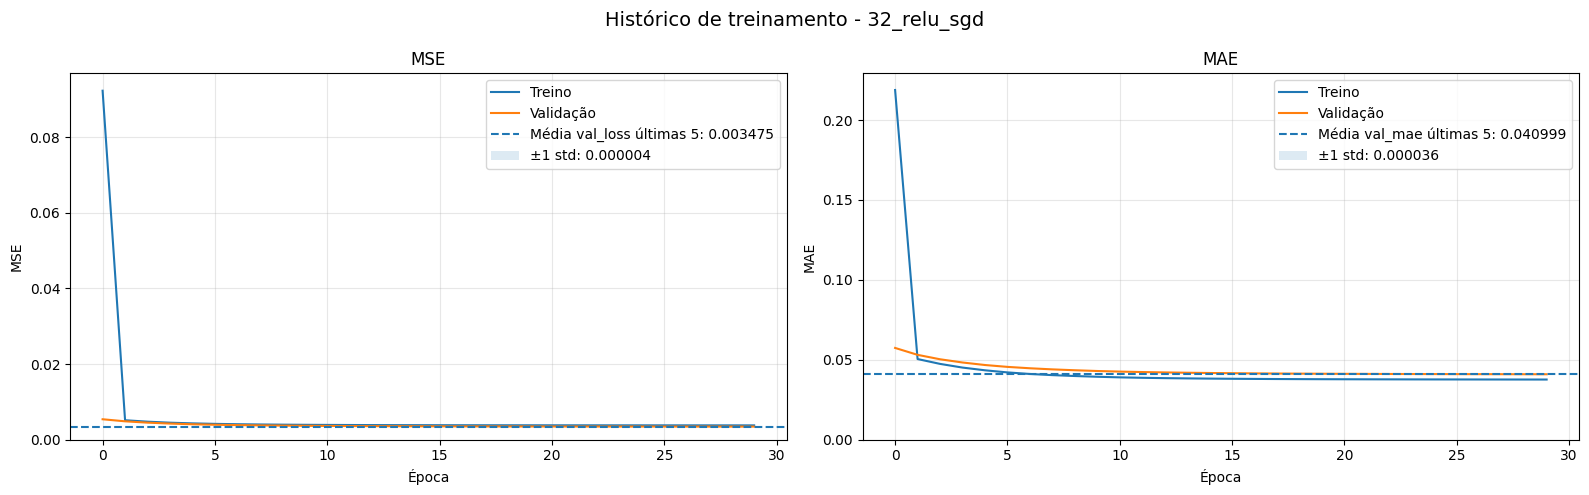

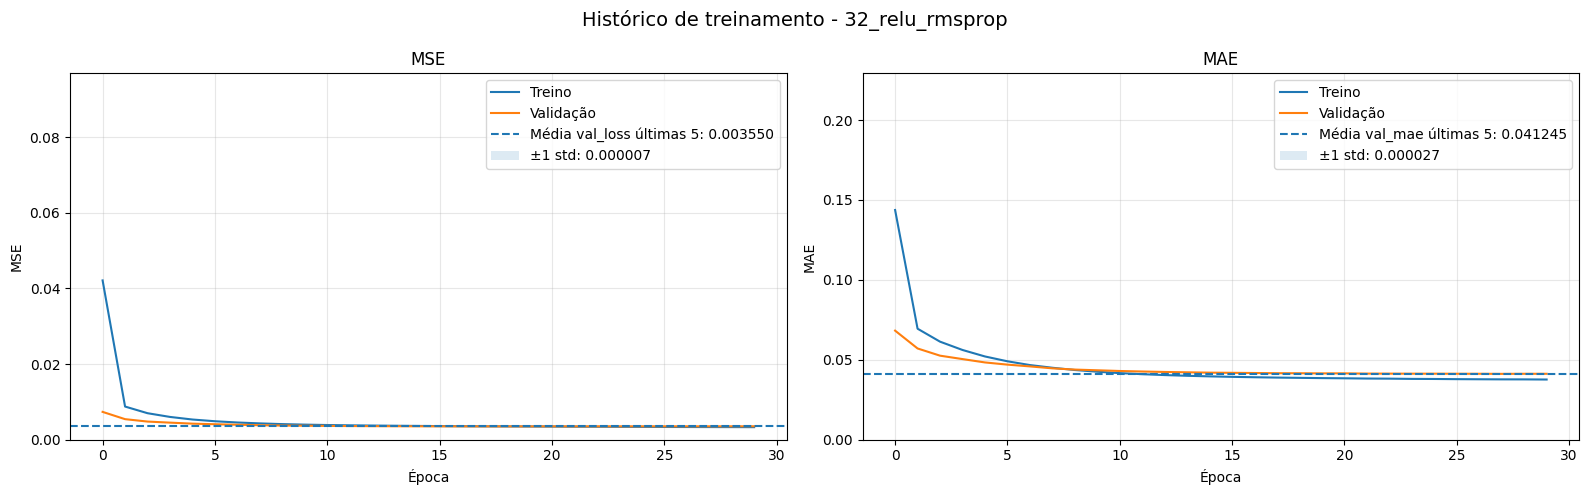

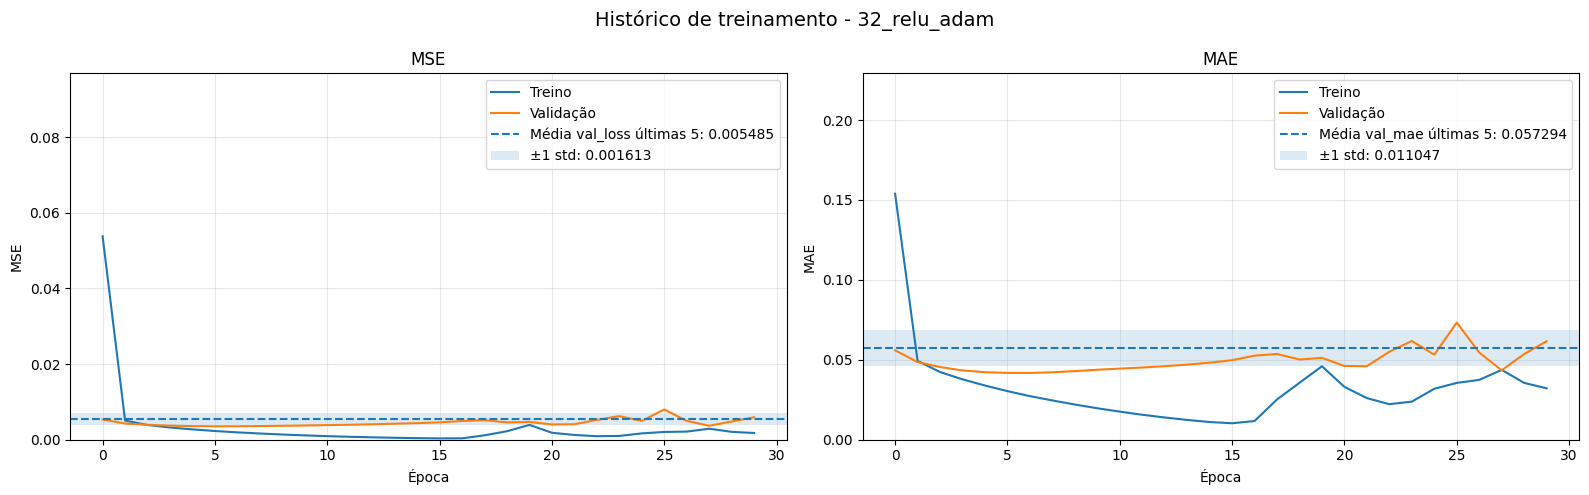

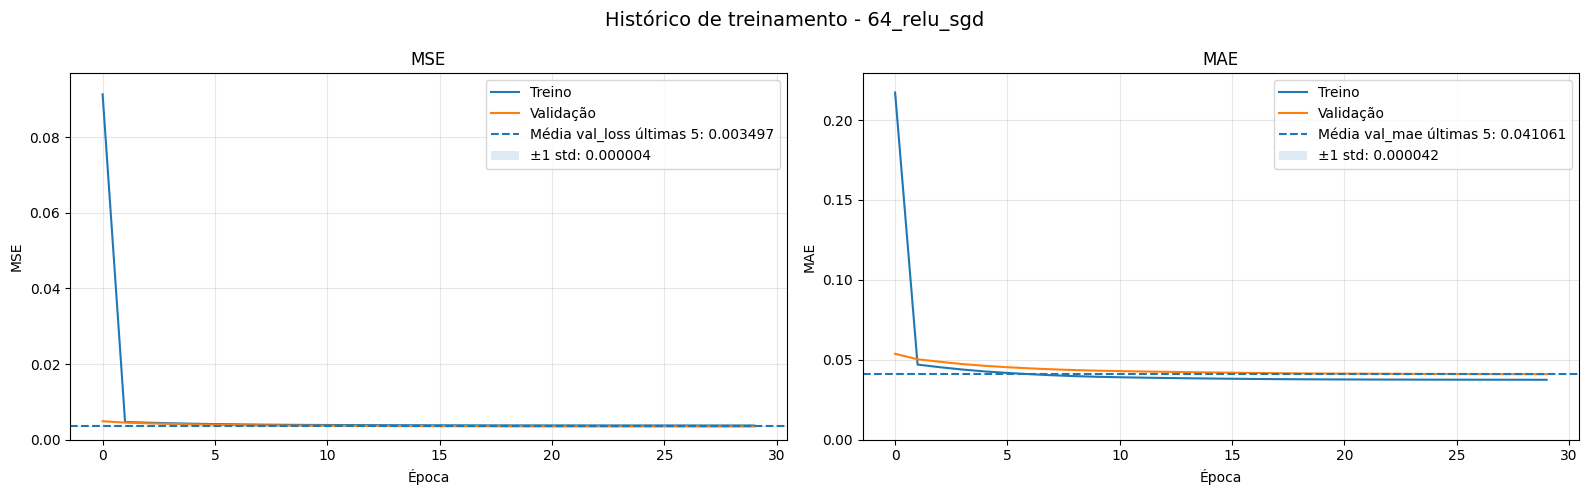

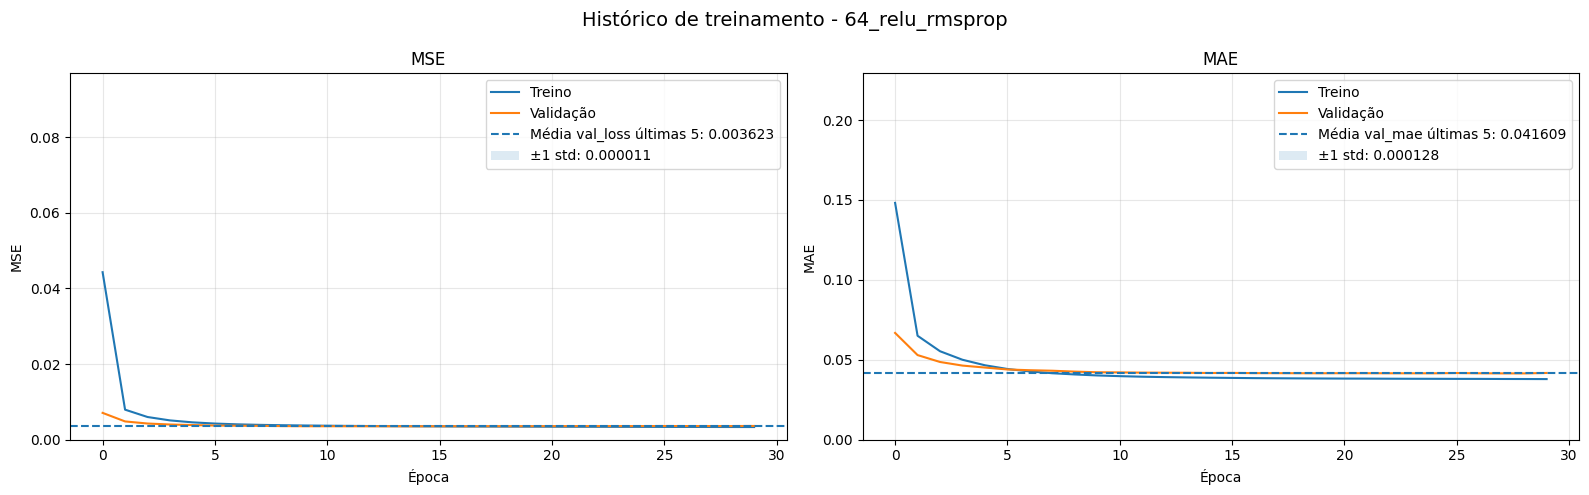

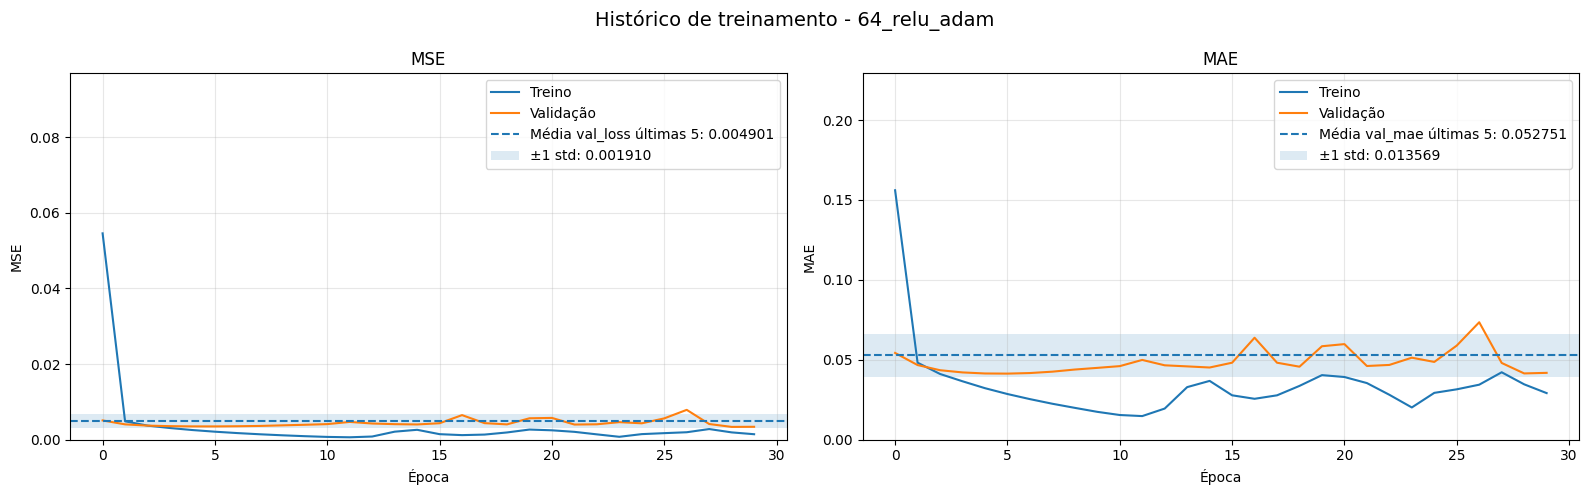

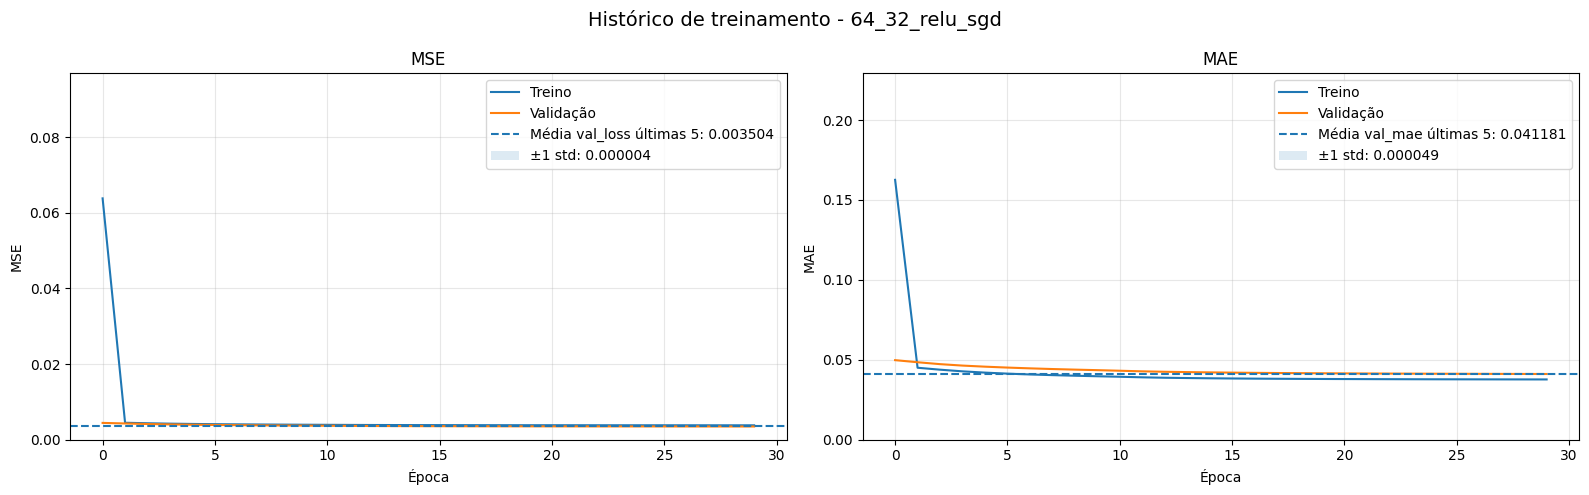

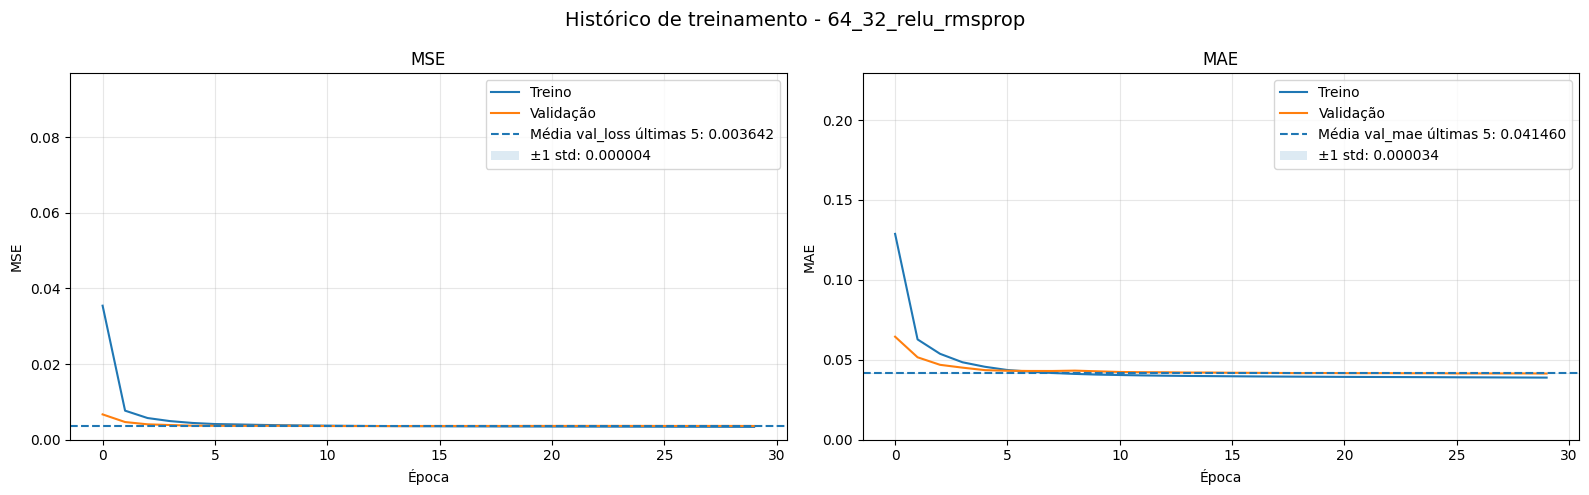

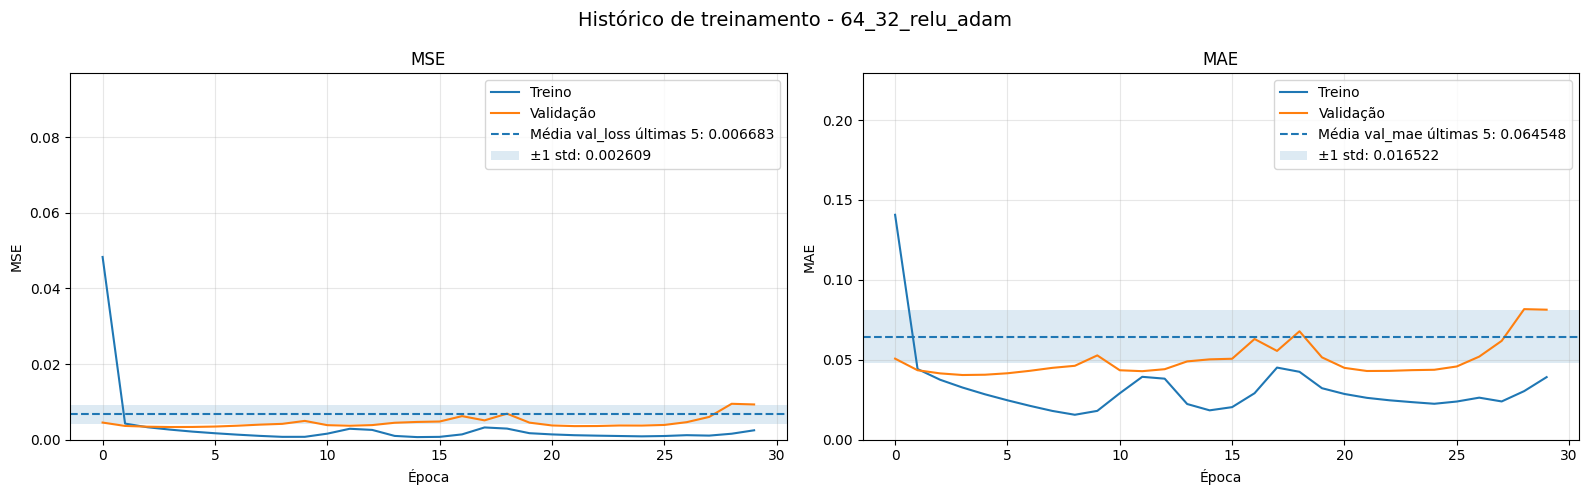

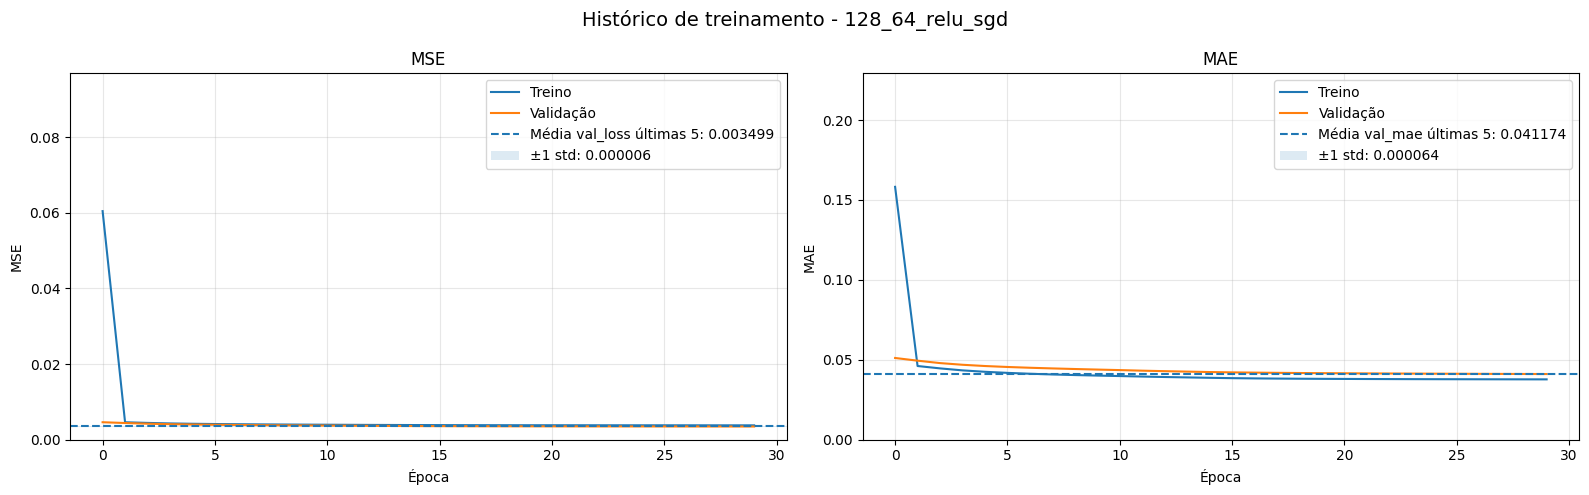

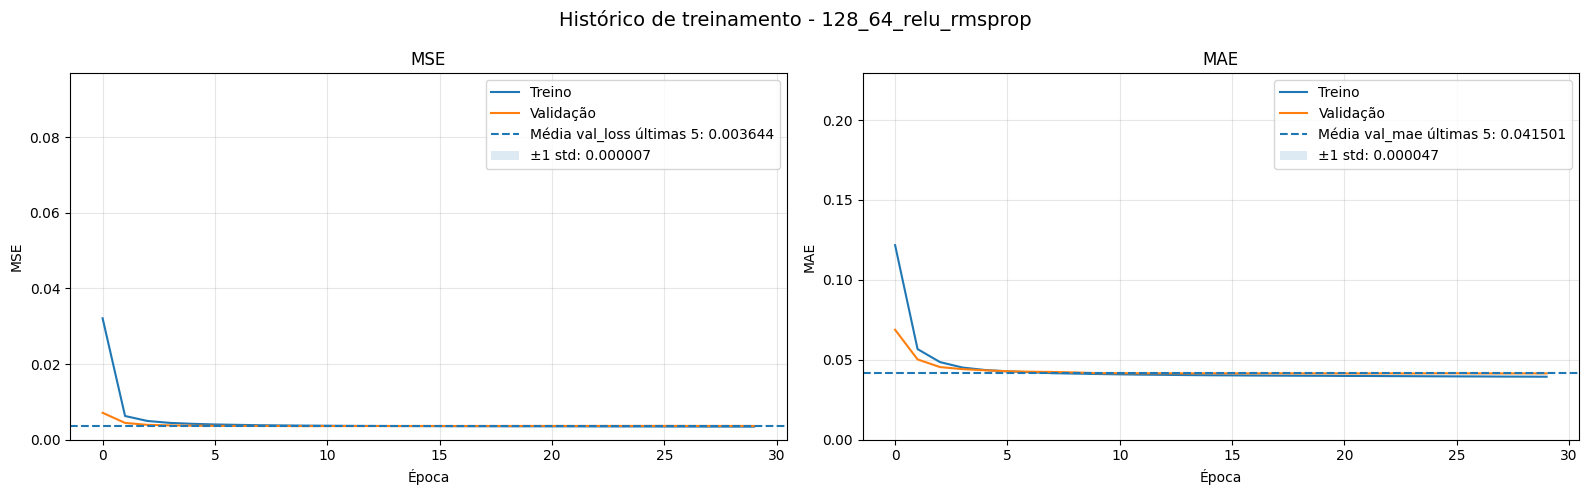

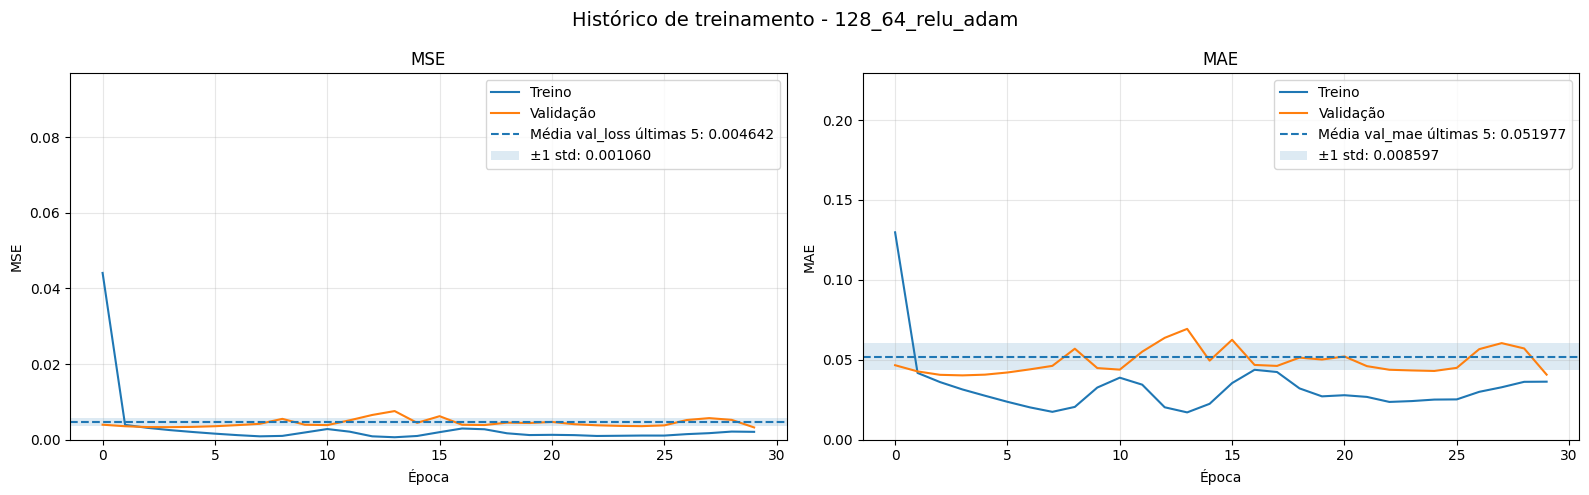

In [36]:
mse_ylim, mae_ylim = calcular_limites_metricas(histories)

for experiment_name, experiment_history in histories.items():
    plot_training_history(
        experiment_history["history"],
        title=experiment_name,
        mse_ylim=mse_ylim,
        mae_ylim=mae_ylim,
        janela=5
    )

Em seguida montamos um dataframe com os principais elementos que vamos utilizar para avaliar os experimentos: loss (MSE), métrica (MAE) da janela e da ultima época, média e desvio padrão da janela, tanto para treino quanto para validação. E terminamos com a melhor MSE e MAE e a época correspondente para a validação.

In [37]:
def gerar_dataframe_metricas_finais(histories, janela=5):
    resultados = []

    for experiment_name, experiment_history in histories.items():
        history_df = pd.DataFrame(experiment_history["history"].history)

        val_loss_last = history_df["val_loss"].tail(janela)
        val_mae_last = history_df["val_mae"].tail(janela)

        loss_last = history_df["loss"].tail(janela)
        mae_last = history_df["mae"].tail(janela)

        resultados.append({
            "experimento": experiment_name,
            "dense_config": experiment_history["dense_config"],
            "optimizer": experiment_history["optimizer"],

            "mean_val_loss_last": val_loss_last.mean(),
            "std_val_loss_last": val_loss_last.std(),
            "mean_val_mae_last": val_mae_last.mean(),
            "std_val_mae_last": val_mae_last.std(),

            "mean_train_loss_last": loss_last.mean(),
            "std_train_loss_last": loss_last.std(),
            "mean_train_mae_last": mae_last.mean(),
            "std_train_mae_last": mae_last.std(),

            "final_val_loss": history_df["val_loss"].iloc[-1],
            "final_val_mae": history_df["val_mae"].iloc[-1],
            "final_train_loss": history_df["loss"].iloc[-1],
            "final_train_mae": history_df["mae"].iloc[-1],

            "best_val_loss": history_df["val_loss"].min(),
            "best_val_loss_epoch": history_df["val_loss"].idxmin() + 1,
            "best_val_mae": history_df["val_mae"].min(),
            "best_val_mae_epoch": history_df["val_mae"].idxmin() + 1,
        })

    return (
        pd.DataFrame(resultados)
        .sort_values(
            by=[
                "mean_val_loss_last",
                "std_val_loss_last",
                "mean_val_mae_last"
            ]
        )
        .reset_index(drop=True)
    )

Ordenamos os resultados obtidos de acordo com o critério:

```python
    by=[
        "mean_val_loss_last",   # critério principal: menor MSE médio de validação nas últimas épocas
        "std_val_loss_last",    # desempate 1: menor oscilação do MSE de validação
        "mean_val_mae_last",    # desempate 2: menor MAE médio de validação
        "std_val_mae_last"      # desempate 3: menor oscilação do MAE de validação
    ]
```

In [38]:
df_metricas_finais = gerar_dataframe_metricas_finais(
    histories,
    janela=5
)

df_metricas_finais = df_metricas_finais.sort_values(
    by=[
        "mean_val_loss_last",   # critério principal: menor MSE médio de validação nas últimas épocas
        "std_val_loss_last",    # desempate 1: menor oscilação do MSE de validação
        "mean_val_mae_last",    # desempate 2: menor MAE médio de validação
        "std_val_mae_last"      # desempate 3: menor oscilação do MAE de validação
    ],
    ascending=True
).reset_index(drop=True)

df_selecao_modelos = df_metricas_finais[
    [
        "experimento",
        "dense_config",
        "optimizer",
        "mean_val_loss_last",
        "std_val_loss_last",
        "mean_val_mae_last",
        "std_val_mae_last",
        "final_val_loss",
        "final_val_mae",
        "best_val_loss",
        "best_val_loss_epoch"
    ]
]

df_selecao_modelos

,experimento,dense_config,optimizer,mean_val_loss_last,std_val_loss_last,mean_val_mae_last,std_val_mae_last,final_val_loss,final_val_mae,best_val_loss,best_val_loss_epoch
0,32_relu_sgd,32_relu,SGD,0.003475,0.000004,0.040999,0.000036,0.003470,0.040955,0.003470,30
1,64_relu_sgd,64_relu,SGD,0.003497,0.000004,0.041061,0.000042,0.003492,0.041010,0.003492,30
2,128_64_relu_sgd,128_64_relu,SGD,0.003499,0.000006,0.041174,0.000064,0.003493,0.041097,0.003493,30
3,64_32_relu_sgd,64_32_relu,SGD,0.003504,0.000004,0.041181,0.000049,0.003499,0.041122,0.003499,30
4,32_relu_rmsprop,32_relu,RMSprop,0.003550,0.000007,0.041245,0.000027,0.003559,0.041246,0.003529,22
5,64_relu_rmsprop,64_relu,RMSprop,0.003623,0.000011,0.041609,0.000128,0.003640,0.041765,0.003556,12
6,64_32_relu_rmsprop,64_32_relu,RMSprop,0.003642,0.000004,0.041460,0.000034,0.003636,0.041402,0.003611,12
7,128_64_relu_rmsprop,128_64_relu,RMSprop,0.003644,0.000007,0.041501,0.000047,0.003637,0.041481,0.003605,10
8,128_64_relu_adam,128_64_relu,Adam,0.004642,0.001060,0.051977,0.008597,0.003249,0.040720,0.003249,30
9,64_relu_adam,64_relu,Adam,0.004901,0.001910,0.052751,0.013569,0.003420,0.041836,0.003388,29


Por fim destacamos o gráfico do melhor modelo escolhido:

In [39]:
melhor_experimento = df_selecao_modelos.iloc[0]["experimento"]

melhor_experimento

'32_relu_sgd'

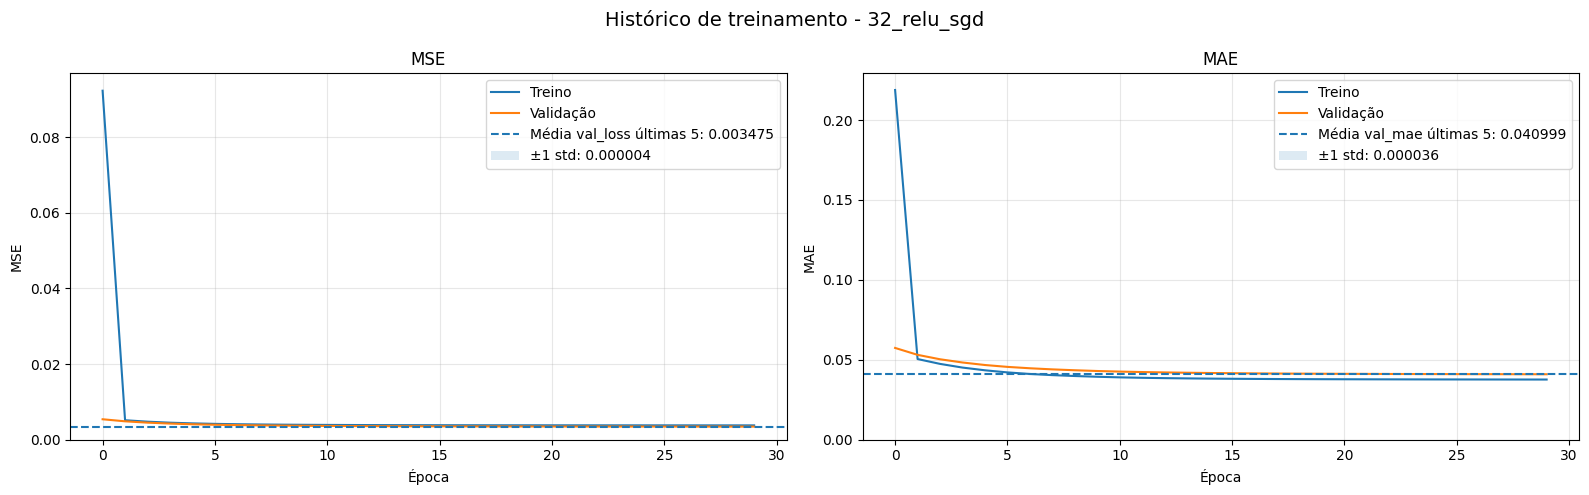

In [40]:
plot_training_history(
    histories[melhor_experimento]["history"],
    title=melhor_experimento,
    mse_ylim=mse_ylim,
    mae_ylim=mae_ylim,
    janela=5
)

### **5º Passo:**
<font size=3>

- Quando definido a melhor rede neural, realize o treinamento final.

### **6º Passo:**
<font size=3>

- Realize a avaliação do modelo com o método `.evaluate()`;
- **Imprima na tela** 10 predições com seus respectivos valores **verdadeiros**.

### **7º Passo:**
<font size=3>

- Salve os parâmetros internos do modelo.

### **8º Passo:**
<font size=3>

- Faça o **relatório da modelagem da arquitetura neural** em uma **célula _markdown_**:
    - Descreva quais foram os tipos de camadas neurais que proporcionaram a melhor performance do modelo;
    - Escreva qual otimizador melhor performou o treinamento.
      

---
## **Questão 2:**
<font size=3>

- Com base na arquitetura neural desenvolvida na **Questão 1**, realize o treinamento *final* e avaliação do modelo considerando a **matriz _embedding_** **GloVe** pré-treinada disponível em $\text{dataset/}$).
    > **Importante:** reinicie o *notebook* antes de retreinar um novo modelo.
    
- **Escreva** em uma **célula _markdown_** qual abordagem apresentou melhor performance. **Justifique** sua hipótese.
   